# 模块一 & 二：数据先行与特征工程
**案例背景**：**泰坦尼克号** EDA（`fetch_openml` 拉取 OpenML 数据，作图用 `matplotlib` / `seaborn`）与模拟预处理实验。本 Notebook 涵盖 **EDA**、缺失值处理、特征编码、特征缩放。

# 特征工程（Feature Engineering）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---
## 迷你示例：创建数据 → EDA → 预处理

下面用**全程代码写入**的虚构小表（部门、司龄、满意度、月通话量、是否流失），演示一条常见流水线：

1. **创建数据**：`numpy` 随机生成 + 人为加入缺失值、离群点。  
2. **EDA**：`train_test_split` 后只在 **训练集** 上看缺失率、`describe`、简单直方图/箱线图（与文档「先划分再探索」一致）。  
3. **数据预处理**：`ColumnTransformer` + `Pipeline`（数值：中位数填充 + `StandardScaler`；类别：众数填充 + `OneHotEncoder`）；**只在 `X_train` 上 `fit`，再 `transform` 训练集与测试集**。

可与后文「泰坦尼克」大规模实战对照阅读。

=== 1. 创建数据：原始表（前 8 行）===


,department,tenure_years,satisfaction,monthly_calls,churn
0,客服,3.4,3.69,500,1
1,客服,3.8,4.79,83,0
2,研发,3.5,2.52,70,0
3,客服,4.3,3.70,70,1
4,销售,6.9,4.96,82,0
5,研发,0.1,2.18,74,1
6,客服,3.5,2.48,77,1
7,客服,4.4,3.16,88,1



=== 2. EDA（仅训练集）：形状 === (225, 5)

缺失率（决定后面用中位数/众数填充）:


,missing_rate
tenure_years,0.044444
satisfaction,0.013333
department,0.000000
monthly_calls,0.000000
churn,0.000000



数值列 describe:


,tenure_years,satisfaction,monthly_calls,churn
count,215.000000,222.000000,225.000000,225.000000
mean,3.973953,3.466036,79.826667,0.493333
std,1.952490,0.808413,9.406077,0.501070
min,0.100000,1.360000,50.000000,0.000000
25%,2.500000,2.900000,73.000000,0.000000
50%,4.100000,3.515000,79.000000,0.000000
75%,5.350000,4.010000,87.000000,1.000000
max,8.700000,5.000000,105.000000,1.000000



类别列 department 频数:


department
客服    101
销售     79
研发     45
Name: count, dtype: int64

C:\Users\prong\AppData\Local\Temp\ipykernel_19068\596502425.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


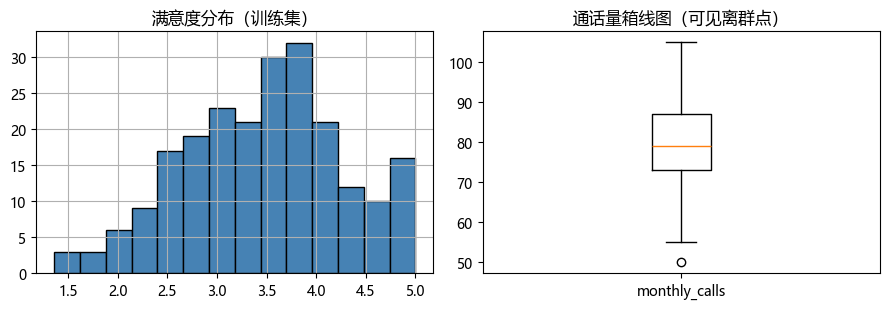


=== 3. 预处理后矩阵形状 ===
X_train_t: (225, 6) | X_test_t: (75, 6)
说明：数值列已中位数填充 + 标准化；类别列已众数填充 + 独热编码；测试集只应用训练集学到的值。


In [40]:
# =============================================================================
# 【本格在干什么】造一张「假想公司员工表」，做三步：看图了解数据 → 划分训练/测试 → 规范预处理
# 您不用死记英文：import 就是「把别人写好的工具拿来用」；变量就是「贴上名字的一盒数据」
# =============================================================================

import numpy as np  # 负责生成随机数、处理数组（很多数字排在一起）
import pandas as pd  # 像 Excel 表格一样管数据，表名叫 DataFrame
import matplotlib.pyplot as plt  # 画图：直方图、箱线图等

# 让图里的中文、负号能正常显示（否则可能出方块或乱码）
plt.rcParams.update(
    {
        "font.sans-serif": [
            "Microsoft YaHei",
            "SimHei",
            "Noto Sans CJK SC",
            "DejaVu Sans",
        ],
        "axes.unicode_minus": False,
    }
)

from IPython.display import display  # 在 Notebook 里把表格漂亮地显示出来
from sklearn.model_selection import train_test_split  # 把数据分成「练习册」和「考卷」
from sklearn.compose import ColumnTransformer  # 不同列可以走不同的处理流水线
from sklearn.pipeline import Pipeline  # 把多步操作连成一条自动化流水线
from sklearn.impute import SimpleImputer  # 某格空着（缺数）时，用什么规则「补上窟窿」
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # 把数字拉到可比尺度；把类别变成电脑认识的编码

# ---------- 第 1 步：造演示数据（现实中您会直接读 CSV/数据库，这里手写方便学） ----------
rng = np.random.default_rng(42)  # 「随机数播种」：42 固定后，每次运行的随机结果一致，便于对照讲义
n = 300  # 假装有 300 名员工
# 部门：按概率随机抽「销售 / 客服 / 研发」
department = rng.choice(["销售", "客服", "研发"], size=n, p=[0.35, 0.45, 0.2])
# 司龄：用「钟形曲线」围绕均值 4 年，再限制在 0.1～15 年之间
tenure_years = rng.normal(4, 2, size=n).clip(0.1, 15)
# 满意度：1～5 分之间浮动
satisfaction = rng.normal(3.5, 0.8, size=n).clip(1, 5)
# 月通话次数：用泊松分布模拟「大约 80 通」的计数型数据
monthly_calls = rng.poisson(lam=80, size=n)

df_demo = pd.DataFrame(
    {
        "department": department,
        "tenure_years": np.round(tenure_years, 1),
        "satisfaction": np.round(satisfaction, 2),
        "monthly_calls": monthly_calls,
    }
)

# 故意挖一些「空格子」、再塞一个超大的通话数，后面才能演示「缺省」和「离群」怎么处理
miss_idx = rng.choice(n, size=25, replace=False)
df_demo.loc[miss_idx[:12], "tenure_years"] = np.nan
df_demo.loc[miss_idx[12:20], "satisfaction"] = np.nan
df_demo.loc[0, "monthly_calls"] = 500  # 离群点：远比别人大

# ---------- 下面按「电脑实际执行的顺序」造假标签 churn（演示用，不是真业务模型）----------
# 思路：先给每一行算一个「风险分」score（小数）；再规定 score>0.55 就当流失 churn=1，否则 churn=0。
#
# 【第 1 句】sat_filled_for_score = ...
#   - df_demo["satisfaction"] 是那 300 个人的满意度列，里面有些是 NaN（空）。
#   - .fillna(3.0) 的意思是：谁空了，就当他是 3 分（中间档），这样后面才能做加减乘除。
#   - 结果是一列长度仍为 300 的数，没有空值了，专门用来参加后面的算分。
sat_filled_for_score = df_demo["satisfaction"].fillna(3.0)
#
# 【第 2 句】tenure_filled_for_score = ...
#   - 同理：司龄列里的空，先当成 2 年，避免「空值没法比大小」。
tenure_filled_for_score = df_demo["tenure_years"].fillna(2.0)
#
# 【第 3～8 句】score = 四项相加（Python 从上往下先把括号里算完，再加起来）
#   项 A：(部门=="客服")→True/False 再 .astype(int) 变成 1/0，乘 0.35 → 客服加 0.35 分风险，非客服加 0。
#   项 B：(5 - 满意度)×0.15 → 满意度越低，(5-分)越大，加分越多（越像要流失）。满意度 5 分时这项为 0。
#   项 C：(司龄<2)→1/0 乘 0.25 → 司龄不到 2 年的多 0.25 分风险。
#   项 D：rng.uniform(0, 0.25, size=n) → 每人随机加 0～0.25 之间的一个小噪声，让数据别太「死板整齐」。
#   四项用 + 连成一条，得到 300 个 score，每人一个。
score = (
    (df_demo["department"] == "客服").astype(int) * 0.35
    + (5 - sat_filled_for_score) * 0.15
    + (tenure_filled_for_score < 2).astype(int) * 0.25
    + rng.uniform(0, 0.25, size=n)
)
#
# 【第 9 句】df_demo["churn"] = ...
#   - (score > 0.55) 对 300 个人逐个比较，得到 True/False。
#   - .astype(int) 把 True 变 1、False 变 0，写进新列 churn，表示「是否流失」的标签。
df_demo["churn"] = (score > 0.55).astype(int)

print("=== 1. 创建数据：原始表（前 8 行）===")
display(df_demo.head(8))

# ---------- 第 2 步：EDA（探索）——先划分，再在「训练集」上看图（避免偷看考卷） ----------
X = df_demo.drop(columns=["churn"])  # X：特征（输入），不要标签列
y = df_demo["churn"]  # y：标签（要预测的是否流失）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)  # 25% 当考卷；stratify 保持流失比例和原来差不多

train_eda_mini = X_train.copy()
train_eda_mini["churn"] = y_train

print("\n=== 2. EDA（仅训练集）：形状 ===", train_eda_mini.shape)
print("\n缺失率（决定后面用中位数/众数填充）:")
display(train_eda_mini.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))
print("\n数值列 describe:")
display(train_eda_mini.select_dtypes(include="number").describe())
print("\n类别列 department 频数:")
display(train_eda_mini["department"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
train_eda_mini["satisfaction"].dropna().hist(bins=14, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("满意度分布（训练集）")
axes[1].boxplot(
    train_eda_mini["monthly_calls"].dropna(),
    vert=True,
    labels=["monthly_calls"],
)
axes[1].set_title("通话量箱线图（可见离群点）")
plt.tight_layout()
plt.show()

# ---------- 第 3 步：预处理——数值列与类别列分开处理；只在训练集上「学规则」----------
num_cols = ["tenure_years", "satisfaction", "monthly_calls"]  # 要当数字算的列
cat_cols = ["department"]  # 文字类别列

# 数值：先补中位数，再标准化（减均值除以标准差，让量级接近）
numeric_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
# 类别：先补出现最多的那一类，再 One-Hot（每一类变成 0/1 若干列）
categorical_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor_mini = ColumnTransformer(
    [
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",  # 没写到的列先丢掉（本例已列全）
)

# 关键记忆点：fit 只在 X_train 上做 = 规则从「练习册」学；transform 对训练、测试都做 = 同一套规则
preprocessor_mini.fit(X_train)
X_train_t = preprocessor_mini.transform(X_train)
X_test_t = preprocessor_mini.transform(X_test)

print("\n=== 3. 预处理后矩阵形状 ===")
print("X_train_t:", X_train_t.shape, "| X_test_t:", X_test_t.shape)
print("说明：数值列已中位数填充 + 标准化；类别列已众数填充 + 独热编码；测试集只应用训练集学到的值。")


---

## EDA 案例：泰坦尼克号生存预测

与知识库 [02-data-preparation.md](https://github.com/prong879/mianjing/blob/main/docs/knowledge/05-ai-ml/machine-learning/02-data-preparation.md) **§ 实战案例** 对应：在划分训练集后，**只在 `X_train`/`y_train` 上**作图，避免用测试集信息做探索导致偏差。


数据来源: `sklearn.datasets.fetch_openml("titanic", version=1)`（OpenML，与 seaborn `load_dataset("titanic")` 为同一批经典特征；离线时可走 sklearn 缓存）。作图使用 `matplotlib` + `seaborn`。


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Pclass     1309 non-null   int64   
 1   Survived   1309 non-null   int64   
 2   name       1309 non-null   str     
 3   Sex        1309 non-null   category
 4   Age        1046 non-null   float64 
 5   SibSp      1309 non-null   int64   
 6   Parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   Fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(2), float64(3), int64(4), str(5)
memory usage: 185.0 KB
            Pclass     Survived          Age        SibSp        Parch  \
count  1309.000000  1309.000000  1046.000000  1309.000000  1309.000000   
mean      2.294882     0.38

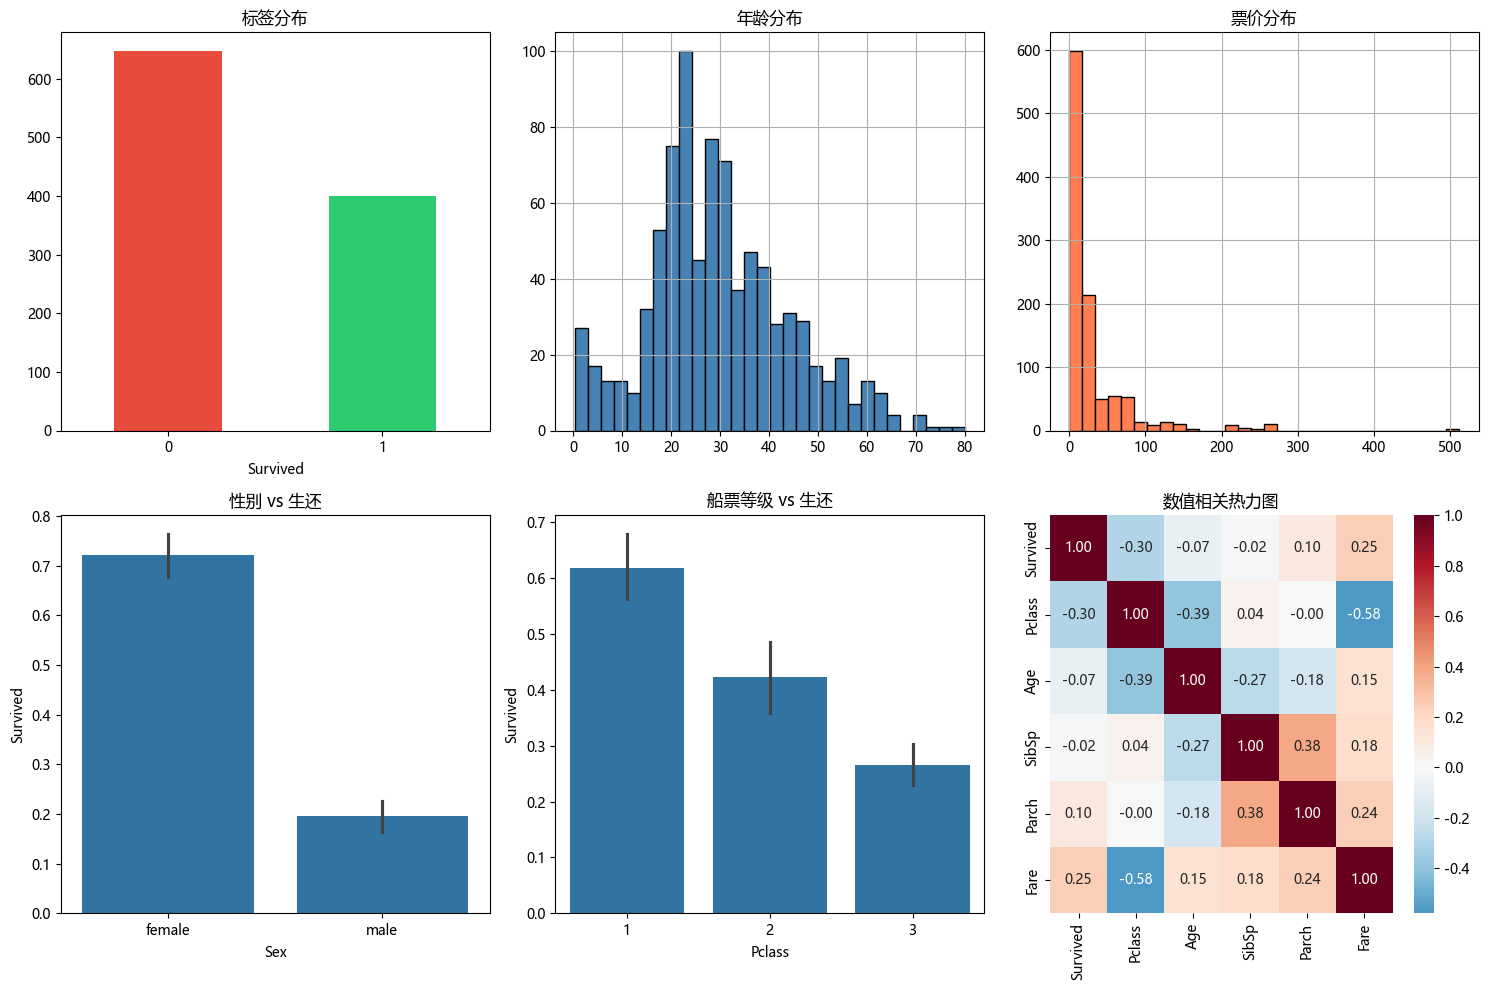

In [41]:
# =============================================================================
# 【本格在干什么】从网上取「泰坦尼克」乘客数据；拆开特征与生死标签；画 6 张小图做第一印象
# =============================================================================

import matplotlib.pyplot as plt  # 画图时常用缩写 plt
import pandas as pd  # 表格数据处理常用缩写 pd
import seaborn as sns  # 在 plt 基础上画更省事的统计图

plt.rcParams.update(
    {
        "font.sans-serif": [
            "Microsoft YaHei",
            "SimHei",
            "Noto Sans CJK SC",
            "WenQuanYi Zen Hei",
            "DejaVu Sans",
        ],
        "axes.unicode_minus": False,  # 坐标轴负号正常显示
    }
)

from sklearn.datasets import fetch_openml  # 从 OpenML 网站下载公开数据集
from sklearn.model_selection import train_test_split

# 下载泰坦尼克数据；as_frame=True 表示要 pandas 表格；parser 让列类型更智能
raw = fetch_openml("titanic", version=1, as_frame=True, parser="auto").frame

# 把「是否生还」统一成 0/1 整数，避免有的地方是字符串、有的地方是数
raw["survived"] = pd.to_numeric(raw["survived"].astype(str), errors="coerce").fillna(0).astype(int)

# 列名改成和教材一致的大写开头（原网站是小写）
titanic = raw.rename(
    columns={
        "survived": "Survived",
        "pclass": "Pclass",
        "sex": "Sex",
        "age": "Age",
        "fare": "Fare",
        "sibsp": "SibSp",
        "parch": "Parch",
    }
)

# .info() 看每列类型与缺失情况；.describe() 看数值列的大致范围（最小最大、平均等）
titanic.info()
print(titanic.describe())

X = titanic.drop(columns=["Survived"])  # 乘客信息当作输入特征
y = titanic["Survived"]  # 生还与否当作要预测的答案

# 80% 练、20% 测；stratify=y 让两边「生还比例」跟总体差不多
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- 下面 6 张图只用 X_train / y_train，这是好习惯：不要对着整张表调心态 ----------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 行 3 列个子图区域

# 图1：标签 0/1 各有多少人（条形图）
y_train.value_counts().sort_index().plot.bar(
    ax=axes[0, 0], color=["#e74c3c", "#2ecc71"], rot=0
)
axes[0, 0].set_title("标签分布")

# 图2：年龄直方图
X_train["Age"].hist(
    bins=30, ax=axes[0, 1], color="steelblue", edgecolor="black"
)
axes[0, 1].set_title("年龄分布")

# 图3：票价直方图
X_train["Fare"].hist(
    bins=30, ax=axes[0, 2], color="coral", edgecolor="black"
)
axes[0, 2].set_title("票价分布")

# 图4～5：需要把标签拼回表，才能按「性别/舱位」看平均生还率
train_data = X_train.copy()
train_data["Survived"] = y_train
sns.barplot(
    x="Sex", y="Survived", data=train_data, ax=axes[1, 0]
)
axes[1, 0].set_title("性别 vs 生还")

sns.barplot(
    x="Pclass", y="Survived", data=train_data, ax=axes[1, 1]
)
axes[1, 1].set_title("船票等级 vs 生还")

# 图6：数值列之间的相关性热力图（颜色深浅表示一起变高变低的程度）
numeric_cols = train_data[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
sns.heatmap(
    numeric_cols.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=axes[1, 2],
)
axes[1, 2].set_title("数值相关热力图")

plt.tight_layout()
plt.show()


---

## EDA：Python 函数与用法（分类案例）

**对应文档**：[02-data-preparation.md](https://github.com/prong879/mianjing/blob/main/docs/knowledge/05-ai-ml/machine-learning/02-data-preparation.md) 中「数据探索分析」小节的 **Python / Jupyter 常用写法速查**。

**前置**：必须先运行上方 **泰坦尼克数据加载、`train_test_split` 划分与六子图概括** 那一格，得到 `X_train`, `y_train`, `X_test`, `y_test`（以及已 `import` 的 `plt` / `sns` / `pd`）。

下面分三格代码：**结构与数据质量** → **单变量** → **双变量与多变量（含可选 PCA）**。


In [42]:
# =============================================================================
# 【本格在干什么】只用训练集，检查表格「长得对不对」：几行几列、缺多少、有没有重复行
# 运行本格前，请先运行上面加载泰坦尼克、train_test_split 那一格
# =============================================================================

from IPython.display import display  # 显示表格比 print 更整齐

# 把「生还标签」临时拼回训练特征，方便一张表上看所有列（名字仍叫 train_eda）
train_eda = X_train.copy()
train_eda["Survived"] = y_train

print("shape（行, 列）:", train_eda.shape)  # 行=人数样本，列=字段数
print("\ndtypes:\n", train_eda.dtypes)  # 每列是文字、小数还是整数
print("\nhead() 前 5 行:")  # 抽样看前几行，像翻书看目录
display(train_eda.head())

# isna() 标出空格；mean() 对 True/False 当 1/0 求平均 = 缺失比例
missing_rate = train_eda.isna().mean().sort_values(ascending=False)
print("\n各列缺失比例（降序）:")
display(missing_rate.to_frame("missing_rate"))

print("完全重复行数 duplicated():", train_eda.duplicated().sum())
print("\n类别列 Sex 的频数 value_counts(dropna=False):")
display(train_eda["Sex"].value_counts(dropna=False))


shape（行, 列）: (1047, 14)

dtypes:
 Pclass          int64
name              str
Sex          category
Age           float64
SibSp           int64
Parch           int64
ticket            str
Fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
Survived        int64
dtype: object

head() 前 5 行:


,Pclass,name,Sex,Age,SibSp,Parch,ticket,Fare,cabin,embarked,boat,body,home.dest,Survived
999,3,"McCarthy, Miss. Catherine 'Katie'",female,NaN,0,0,383123,7.7500,NaN,Q,15 16,NaN,NaN,1
392,2,"del Carlo, Mrs. Sebastiano (Argenia Genovesi)",female,24.0,1,0,SC/PARIS 2167,27.7208,NaN,C,12,NaN,"Lucca, Italy / California",1
628,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.2750,NaN,S,NaN,NaN,"Sweden Winnipeg, MN",0
1165,3,"Saad, Mr. Khalil",male,25.0,0,0,2672,7.2250,NaN,C,NaN,NaN,NaN,0
604,3,"Abelseth, Miss. Karen Marie",female,16.0,0,0,348125,7.6500,NaN,S,16,NaN,"Norway Los Angeles, CA",1



各列缺失比例（降序）:


,missing_rate
body,0.912130
cabin,0.785100
boat,0.628462
home.dest,0.429799
Age,0.199618
Fare,0.000955
Parch,0.000000
SibSp,0.000000
Sex,0.000000
name,0.000000


完全重复行数 duplicated(): 0

类别列 Sex 的频数 value_counts(dropna=False):


Sex
male      675
female    372
Name: count, dtype: int64

,Pclass,Age,SibSp,Parch,Fare
count,1047.000000,838.000000,1047.000000,1047.000000,1046.000000
mean,2.314231,29.604316,0.484241,0.385864,32.166838
std,0.831742,14.362736,1.010220,0.862492,48.915820
min,1.000000,0.333300,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,0.000000,13.816650
75%,3.000000,38.375000,1.000000,0.000000,30.923950
max,3.000000,80.000000,8.000000,9.000000,512.329200


偏度 skew:


Pclass   -0.641962
Age       0.443097
SibSp     3.602345
Parch     3.710053
Fare      4.139076
dtype: float64

峰度 kurtosis:


Pclass    -1.255067
Age        0.220814
SibSp     17.681430
Parch     23.082589
Fare      24.444495
dtype: float64

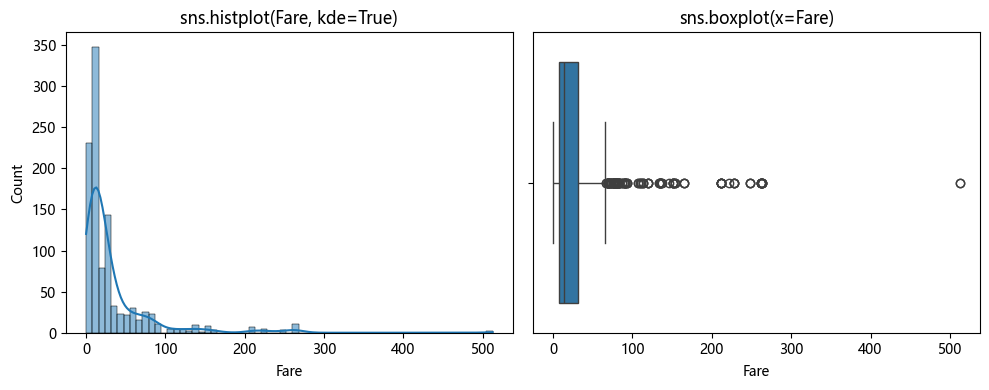

In [43]:
# =============================================================================
# 【本格在干什么】单变量：看几个数字列的统计摘要 + 偏斜程度 + 票价怎么分布（直方图与箱线图）
# =============================================================================

# 从训练表 train_eda 里挑出我们关心的数值列（如果列不存在就跳过，防止报错）
num_cols = [c for c in ["Pclass", "Age", "SibSp", "Parch", "Fare"] if c in train_eda.columns]
display(train_eda[num_cols].describe())  # count/mean/std/分位数等一读就懂
print("偏度 skew:")  # 分布往哪边「拖尾巴」；绝对值越大越不对称
display(train_eda[num_cols].skew(numeric_only=True))
print("峰度 kurtosis:")  # 尾巴厚薄；很大时往往有极端大或极端小的值
display(train_eda[num_cols].kurtosis(numeric_only=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# 左：直方图 + 平滑曲线 kde，看票价集中在哪一段
sns.histplot(train_eda["Fare"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("sns.histplot(Fare, kde=True)")
# 右：箱线图，中间的箱子是「中间一半人」的范围，外面的点是异常值嫌疑
sns.boxplot(x=train_eda["Fare"], ax=axes[1])
axes[1].set_title("sns.boxplot(x=Fare)")
plt.tight_layout()
plt.show()


Pearson 相关（默认 method='pearson'）:


,Survived,Pclass,Age,Fare
Survived,1.000000,-0.302553,-0.071200,0.249800
Pclass,-0.302553,1.000000,-0.394910,-0.583979
Age,-0.071200,-0.394910,1.000000,0.150807
Fare,0.249800,-0.583979,0.150807,1.000000


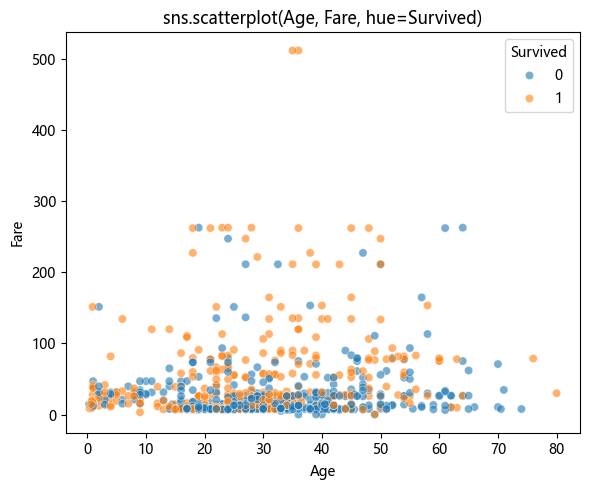

pd.crosstab(Sex, Survived, margins=True):


Survived,0,1,All
Sex,,,
female,104,268,372
male,543,132,675
All,647,400,1047


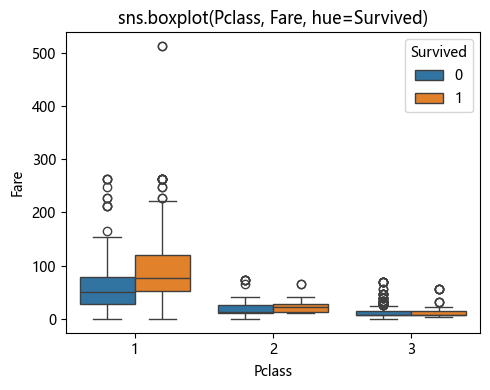

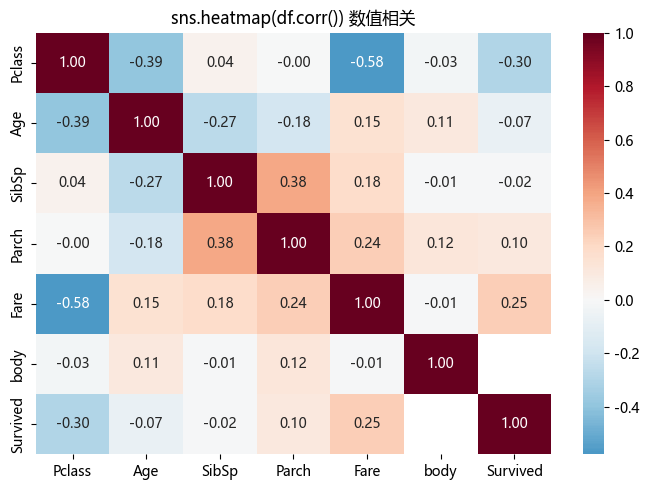

PCA 前两主成分方差占比 explained_variance_ratio_: [0.35439835 0.31599688]


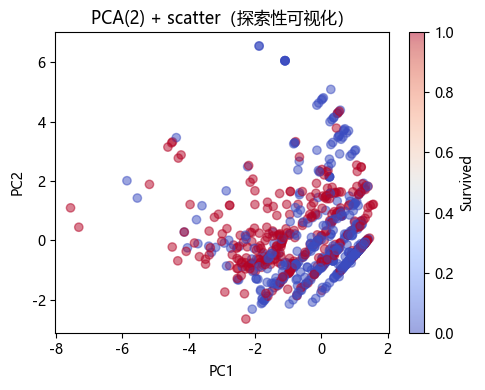

In [44]:
# =============================================================================
# 【本格在干什么】多列一起看：相关矩阵、散点图、交叉表、按舱位看的票价箱线图；最后演示 PCA 压成 2 维散点
# PCA 这里只为「看一眼结构」，真正建模请用 Pipeline 按部就班做
# =============================================================================

sub = train_eda[["Survived", "Pclass", "Age", "Fare"]].dropna()
print("Pearson 相关（默认 method='pearson'）:")
display(sub.corr(numeric_only=True))

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=train_eda, x="Age", y="Fare", hue="Survived", alpha=0.6, ax=ax)
ax.set_title("sns.scatterplot(Age, Fare, hue=Survived)")
plt.tight_layout()
plt.show()

ct = pd.crosstab(train_eda["Sex"], train_eda["Survived"], margins=True)
print("pd.crosstab(Sex, Survived, margins=True):")
display(ct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=train_eda, x="Pclass", y="Fare", hue="Survived", ax=ax)
ax.set_title("sns.boxplot(Pclass, Fare, hue=Survived)")
plt.tight_layout()
plt.show()

# ---------- 全部数值列的相关热力图 ----------
num_only = train_eda.select_dtypes(include="number")
corr = num_only.corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("sns.heatmap(df.corr()) 数值相关")
plt.tight_layout()
plt.show()

# ---------- PCA：把多维压成 2 维画图，颜色=是否生还（下方 fillna 仅演示用） ----------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feat_cols = [c for c in ["Pclass", "Age", "SibSp", "Parch", "Fare"] if c in train_eda.columns]
feat = train_eda[feat_cols].copy()
feat = feat.fillna(feat.median(numeric_only=True))  # 正式建模请用 Imputer 在 Pipeline 里做
Z = StandardScaler().fit_transform(feat)  # PCA 前通常先标准化
pca_demo = PCA(n_components=2, random_state=42)
coords = pca_demo.fit_transform(Z)
print("PCA 前两主成分方差占比 explained_variance_ratio_:", pca_demo.explained_variance_ratio_)
plt.figure(figsize=(5, 4))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=train_eda["Survived"], cmap="coolwarm", alpha=0.5)
plt.colorbar(sc, label="Survived")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA(2) + scatter（探索性可视化）")
plt.tight_layout()
plt.show()


---

## 缺失值处理



来源: 面经知识库 05-feature-engineering.md §1.2


In [45]:
# =============================================================================
# 【本格在干什么】演示「窟窿怎么补」：年龄用中位数、工资用平均数、城市用出现最多的那个
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# 手工造 6 行小表，里面有 blank（NaN），和真实业务里的漏填很像
data = {
    "Age": [25, 30, np.nan, 45, 35, np.nan],
    "Salary": [5000, 6000, 5500, np.nan, 8000, 7500],
    "City": ["Beijing", "Shanghai", "Guangzhou", np.nan, "Beijing", "Shanghai"],
}
df = pd.DataFrame(data)
print("--- 原始包含缺失值的数据 ---")
print(df)
print("\n")

# SimpleImputer：fit 时在这列上「统计该用什么数去填」；transform 真正填进表
age_imputer = SimpleImputer(strategy="median")  # 中位数：不怕极端大或极端小的一两条
df["Age_filled"] = age_imputer.fit_transform(df[["Age"]]).ravel()

salary_imputer = SimpleImputer(strategy="mean")  # 平均数：平时说「大概挣多少」的直觉
df["Salary_filled"] = salary_imputer.fit_transform(df[["Salary"]]).ravel()

city_imputer = SimpleImputer(strategy="most_frequent")  # 众数：填「最常见城市」
# Pandas 3.x：object 列不能直接赋 2D 数组，.ravel() 压成一列再塞进 DataFrame
df["City_filled"] = city_imputer.fit_transform(df[["City"]]).ravel()

print("--- 填充后的数据 ---")
print(df[["Age_filled", "Salary_filled", "City_filled"]])


--- 原始包含缺失值的数据 ---
    Age  Salary       City
0  25.0  5000.0    Beijing
1  30.0  6000.0   Shanghai
2   NaN  5500.0  Guangzhou
3  45.0     NaN        NaN
4  35.0  8000.0    Beijing
5   NaN  7500.0   Shanghai


--- 填充后的数据 ---
   Age_filled  Salary_filled City_filled
0        25.0         5000.0     Beijing
1        30.0         6000.0    Shanghai
2        32.5         5500.0   Guangzhou
3        45.0         6400.0     Beijing
4        35.0         8000.0     Beijing
5        32.5         7500.0    Shanghai


---

## 类别特征编码



来源: 面经知识库 05-feature-engineering.md §2.2


In [46]:
# =============================================================================
# 【本格在干什么】把「学历」变成 1,2,3,4；把「颜色」拆成多列 0/1（独热编码），电脑更爱算这种格式
# =============================================================================

import pandas as pd

df = pd.DataFrame(
    {
        "Education": ["High School", "Bachelor", "Master", "PhD", "Bachelor"],
        "Color": ["Red", "Blue", "Green", "Red", "Blue"],
    }
)

# 字典映射：有序类别（学历有高低）时常用简单编号
edu_mapping = {"High School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df["Education_Encoded"] = df["Education"].map(edu_mapping)

# get_dummies：每个颜色变成一列，是这种颜色为 True，否则 False（等价 0/1）
df_onehot = pd.get_dummies(df, columns=["Color"], prefix="Color")

print("--- 编码后的数据 ---")
print(df_onehot)


--- 编码后的数据 ---
     Education  Education_Encoded  Color_Blue  Color_Green  Color_Red
0  High School                  0       False        False       True
1     Bachelor                  1        True        False      False
2       Master                  2       False         True      False
3          PhD                  3       False        False       True
4     Bachelor                  1        True        False      False


---

## 特征缩放



来源: 面经知识库 05-feature-engineering.md §3.2


In [47]:
# =============================================================================
# 【本格在干什么】让不同量纲的数字能公平比较：标准化（围绕 0 抖一抖） vs 最小最大缩放到 0～1
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.DataFrame(
    {
        "Age": [25, 30, 35, 40, 45],
        "Income": [50000, 60000, 150000, 80000, 90000],  # 收入数字比年龄大很多，不缩放会「喧宾夺主」
    }
)

std_scaler = StandardScaler()  # 每列变近似：均值 0、方差 1
df_std = pd.DataFrame(std_scaler.fit_transform(df), columns=["Age_Std", "Income_Std"])

minmax_scaler = MinMaxScaler()  # 每列线性压到 [0,1]，最小→0，最大→1
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=["Age_MinMax", "Income_MinMax"])

print("--- 原始数据 ---")
print(df)
print("\n--- 标准化 (均值0, 方差1) ---")
print(df_std)
print("\n--- 归一化 (范围 0-1) ---")
print(df_minmax)


--- 原始数据 ---
   Age  Income
0   25   50000
1   30   60000
2   35  150000
3   40   80000
4   45   90000

--- 标准化 (均值0, 方差1) ---
    Age_Std  Income_Std
0 -1.414214   -1.028992
1 -0.707107   -0.743161
2  0.000000    1.829318
3  0.707107   -0.171499
4  1.414214    0.114332

--- 归一化 (范围 0-1) ---
   Age_MinMax  Income_MinMax
0        0.00            0.0
1        0.25            0.1
2        0.50            1.0
3        0.75            0.3
4        1.00            0.4
